In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import linregress

# Global visual settings for plots
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
print("=== All libraries imported and plotting themes initialized successfully ===")

=== All libraries imported and plotting themes initialized successfully ===


In [3]:
# 1. Load Data
file_path = "contact_angles_summary_Total.csv"
df = pd.read_csv(file_path)

=== STATISTICAL SUMMARY PER FORMULATION (Automatic Algorithm) ===
   Formulation_ID  Replicates       Mean       Std     CV (%)
0      Formula_30           3  24.493333  3.114199  12.714475
1      Formula_26           3  26.953333  3.278938  12.165241
2      Formula_31           3  27.423333  0.899018   3.278296
3      Formula_27           3  27.996667  2.320007   8.286726
4      Formula_29           3  28.090000  1.531894   5.453522
5       Formula_7           3  28.146667  2.885920  10.253150
6      Formula_11           3  28.966667  2.568274   8.866310
7       Formula_6           3  29.110000  1.260119   4.328818
8      Formula_15           3  29.573333  1.427807   4.828022
9       Formula_2           3  29.866667  1.970846   6.598814
10     Formula_10           3  30.150000  1.194529   3.961954
11     Formula_22           3  31.020000  1.906856   6.147183
12     Formula_14           3  31.050000  0.492443   1.585967
13      Formula_8           3  31.233333  1.606497   5.143534
14  

C:\Users\nahid.salimi\AppData\Local\Temp\ipykernel_1932\3182349795.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_labels, rotation=45, ha='right', fontsize=9, fontweight='bold')


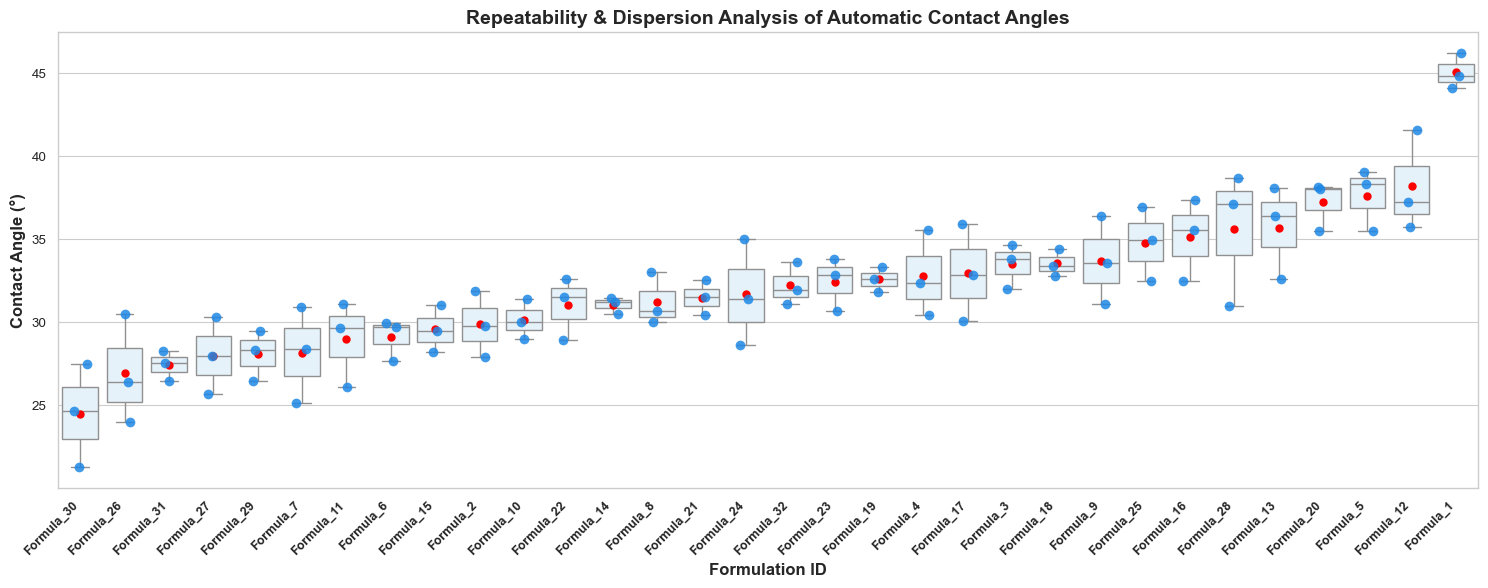

In [4]:

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Rename columns according to exact Excel headers
col_map = {
    'Fromula_ID': 'Formulation_ID',
    'Average Angle (deg)': 'Contact_Angle',
    'Fit RMSE (px)': 'Fit_RMSE'
}
df.rename(columns=col_map, inplace=True)

# Fallback for alternative column names if needed
for col in df.columns:
    if 'Average' in col and 'Fiji' not in col and 'Contact_Angle' not in df.columns:
        df.rename(columns={col: 'Contact_Angle'}, inplace=True)
    if 'RMSE' in col and 'Fit_RMSE' not in df.columns:
        df.rename(columns={col: 'Fit_RMSE'}, inplace=True)

# 2. Add Replicate Numbering per Formulation (1, 2, 3)
df['Replicate'] = df.groupby('Formulation_ID').cumcount() + 1

# 3. Filter Outliers (Remove high RMSE fits, e.g., RMSE > 4.0)
if 'Fit_RMSE' in df.columns:
    df_clean = df[df['Fit_RMSE'] <= 4.0].copy()
else:
    df_clean = df.copy()

# 4. Statistical Analysis: Calculate Mean, Standard Deviation (Std), and CV (%) per Formulation
stats_df = df_clean.groupby('Formulation_ID')['Contact_Angle'].agg(
    Mean='mean',
    Std='std',
    Replicates='count'
).reset_index()

# Calculate Coefficient of Variation (CV %)
stats_df['CV (%)'] = (stats_df['Std'] / stats_df['Mean']) * 100
stats_df['Label'] = stats_df['Formulation_ID']

# Sort stats dataframe by Mean Contact Angle in ascending order
stats_df = stats_df.sort_values(by='Mean').reset_index(drop=True)

print("=== STATISTICAL SUMMARY PER FORMULATION (Automatic Algorithm) ===")
print(stats_df[['Formulation_ID', 'Replicates', 'Mean', 'Std', 'CV (%)']])

# 5. Visualization: Ranked Boxplot of Automatic Contact Angles
order_labels = stats_df['Label'].tolist()
id_to_label = dict(zip(stats_df['Formulation_ID'], stats_df['Label']))
df_clean['Plot_Label'] = df_clean['Formulation_ID'].map(id_to_label)

fig, ax = plt.subplots(figsize=(15, 6))

sns.boxplot(
    data=df_clean,
    x='Plot_Label',
    y='Contact_Angle',
    order=order_labels,
    ax=ax,
    color='#E3F2FD',
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 5}
)

sns.stripplot(
    data=df_clean,
    x='Plot_Label',
    y='Contact_Angle',
    order=order_labels,
    ax=ax,
    color='#1E88E5',
    size=7,
    jitter=0.15,
    alpha=0.85
)

ax.set_xticklabels(order_labels, rotation=45, ha='right', fontsize=9, fontweight='bold')
ax.set_ylabel("Contact Angle (°)", fontweight='bold', fontsize=12)
ax.set_xlabel("Formulation ID", fontweight='bold', fontsize=12)
ax.set_title("Repeatability & Dispersion Analysis of Automatic Contact Angles", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig("Automatic_Contact_Angle_Boxplot.png", dpi=300, bbox_inches='tight')
plt.savefig("Automatic_Contact_Angle_Boxplot.pdf", dpi=300, bbox_inches='tight')
plt.show()

Number of validation images: 30

=== Manual Fiji vs Automatic Python Agreement Metrics ===
R²: 0.9335 | MAE: 1.27° | RMSE: 1.52°
Parity slope: 0.968 | Intercept: 0.064°
Mean bias: -0.97° | 95% LoA: -3.31° to 1.37°


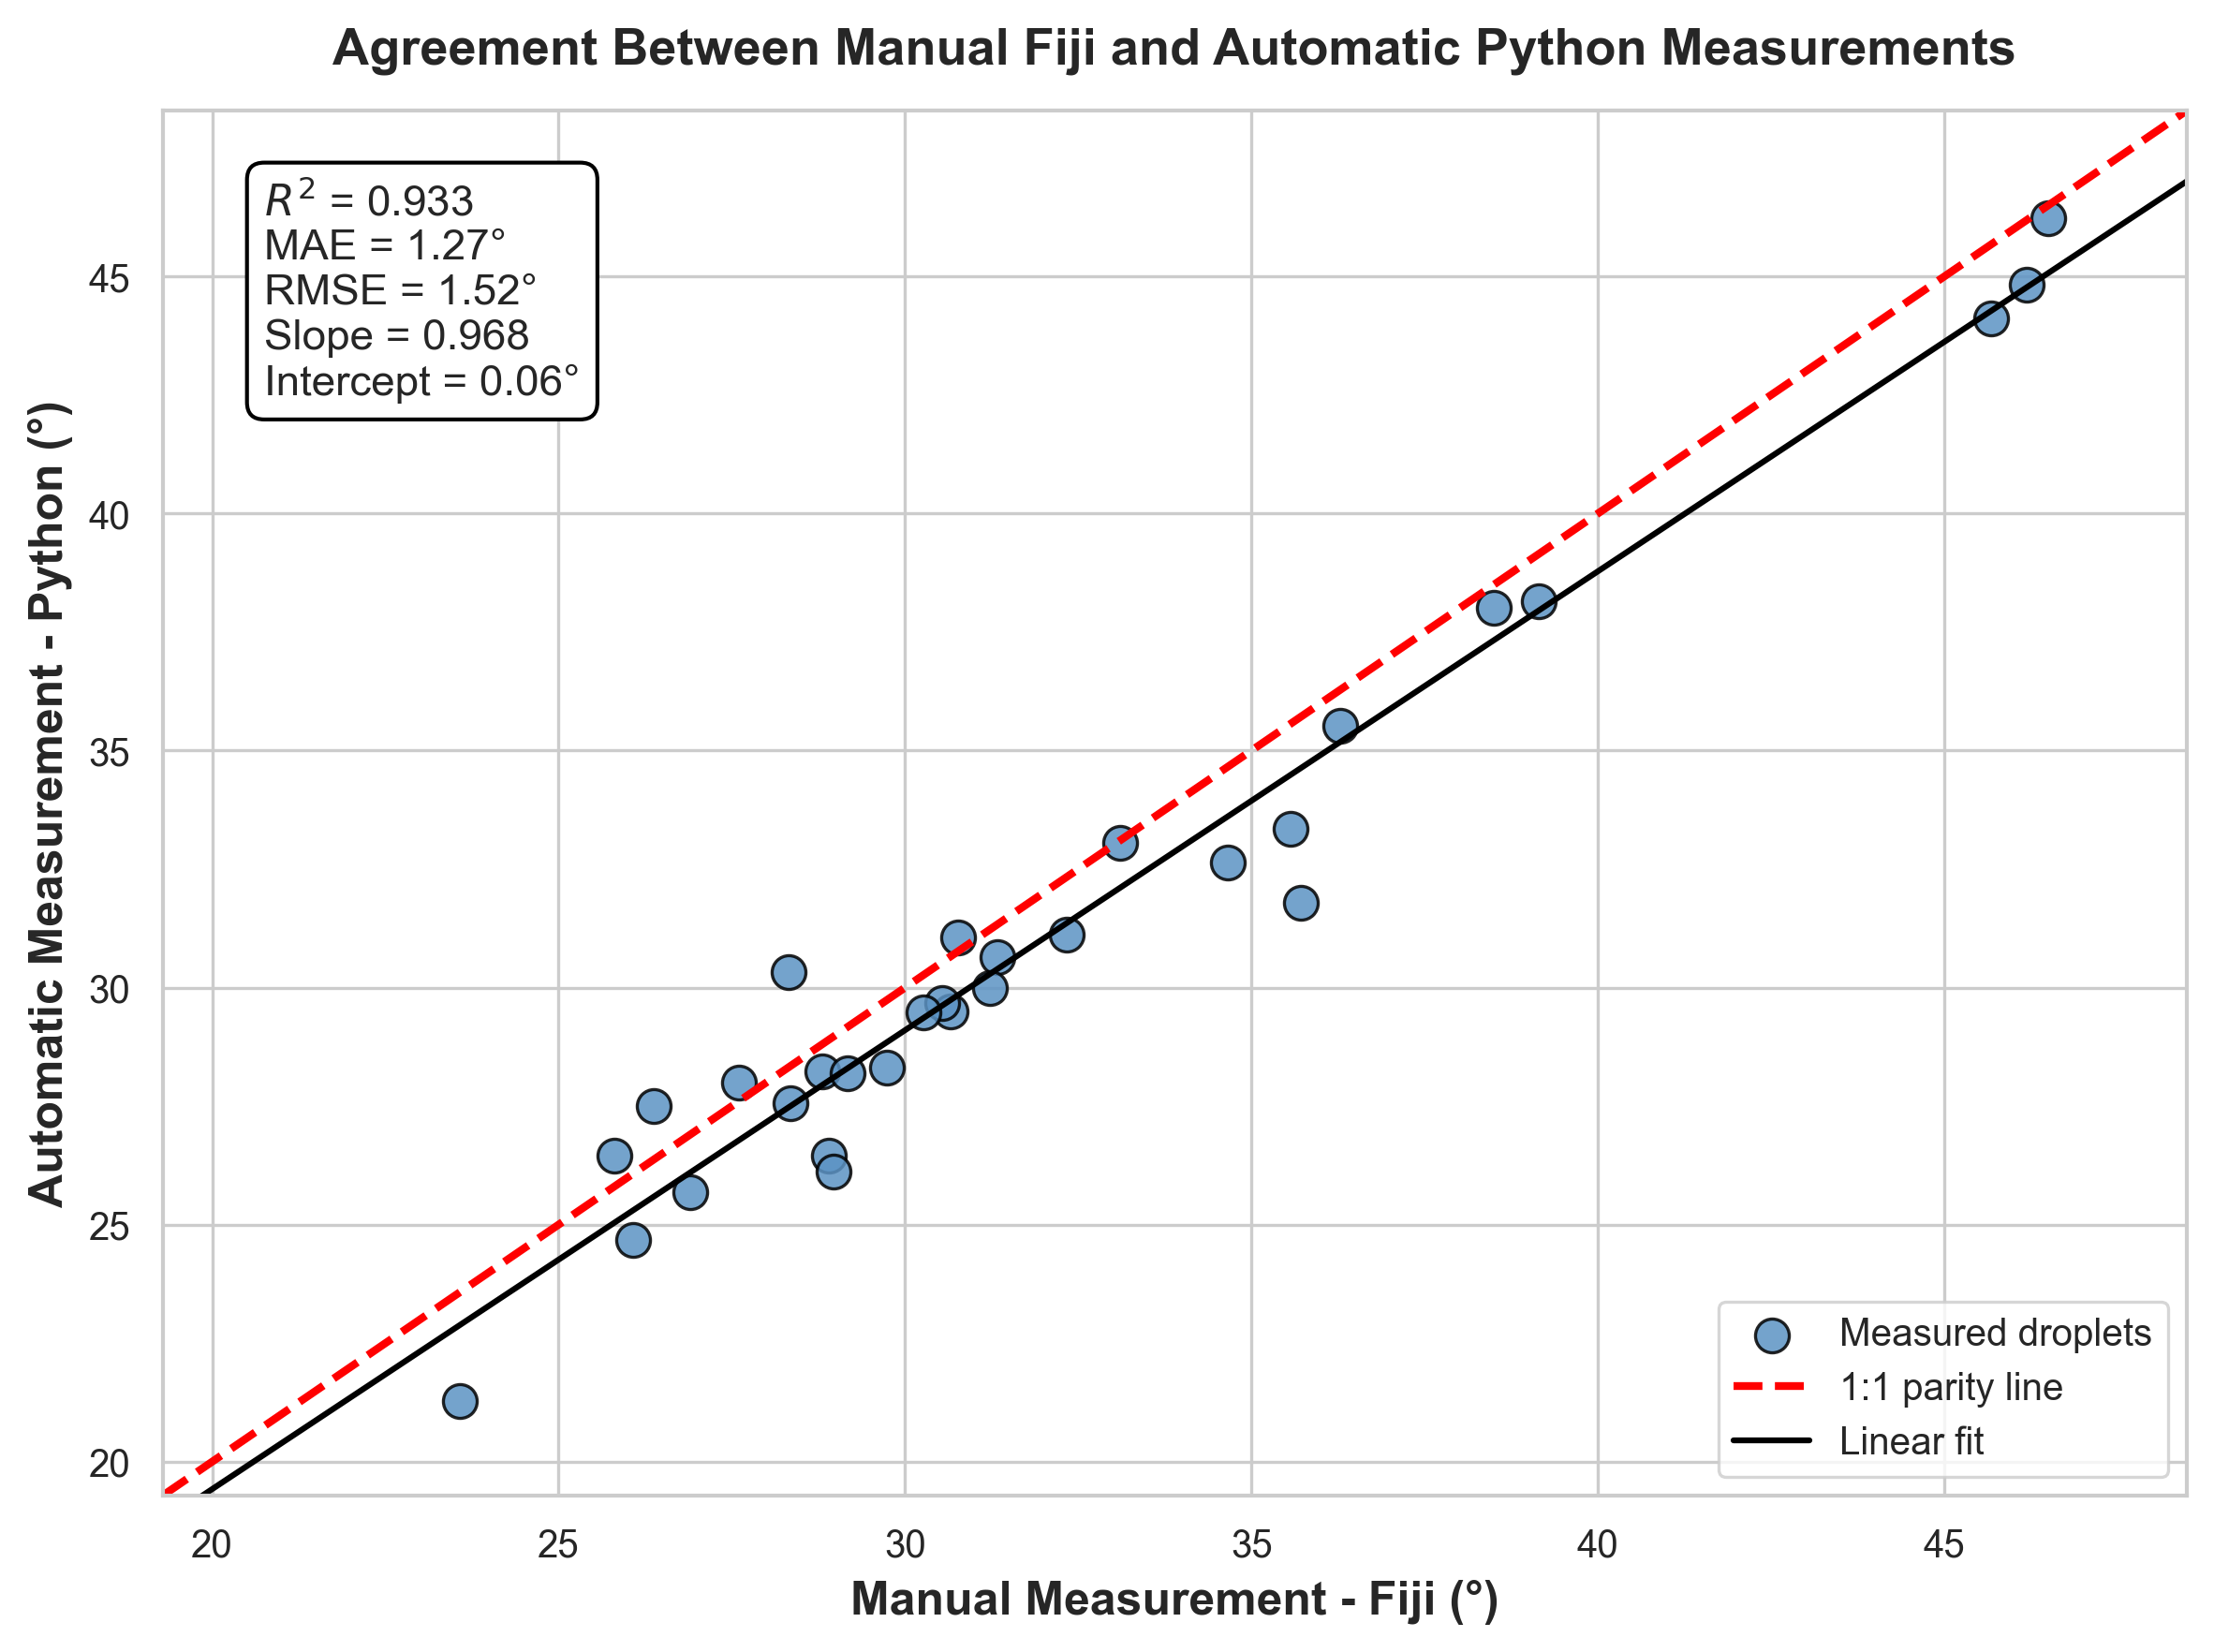

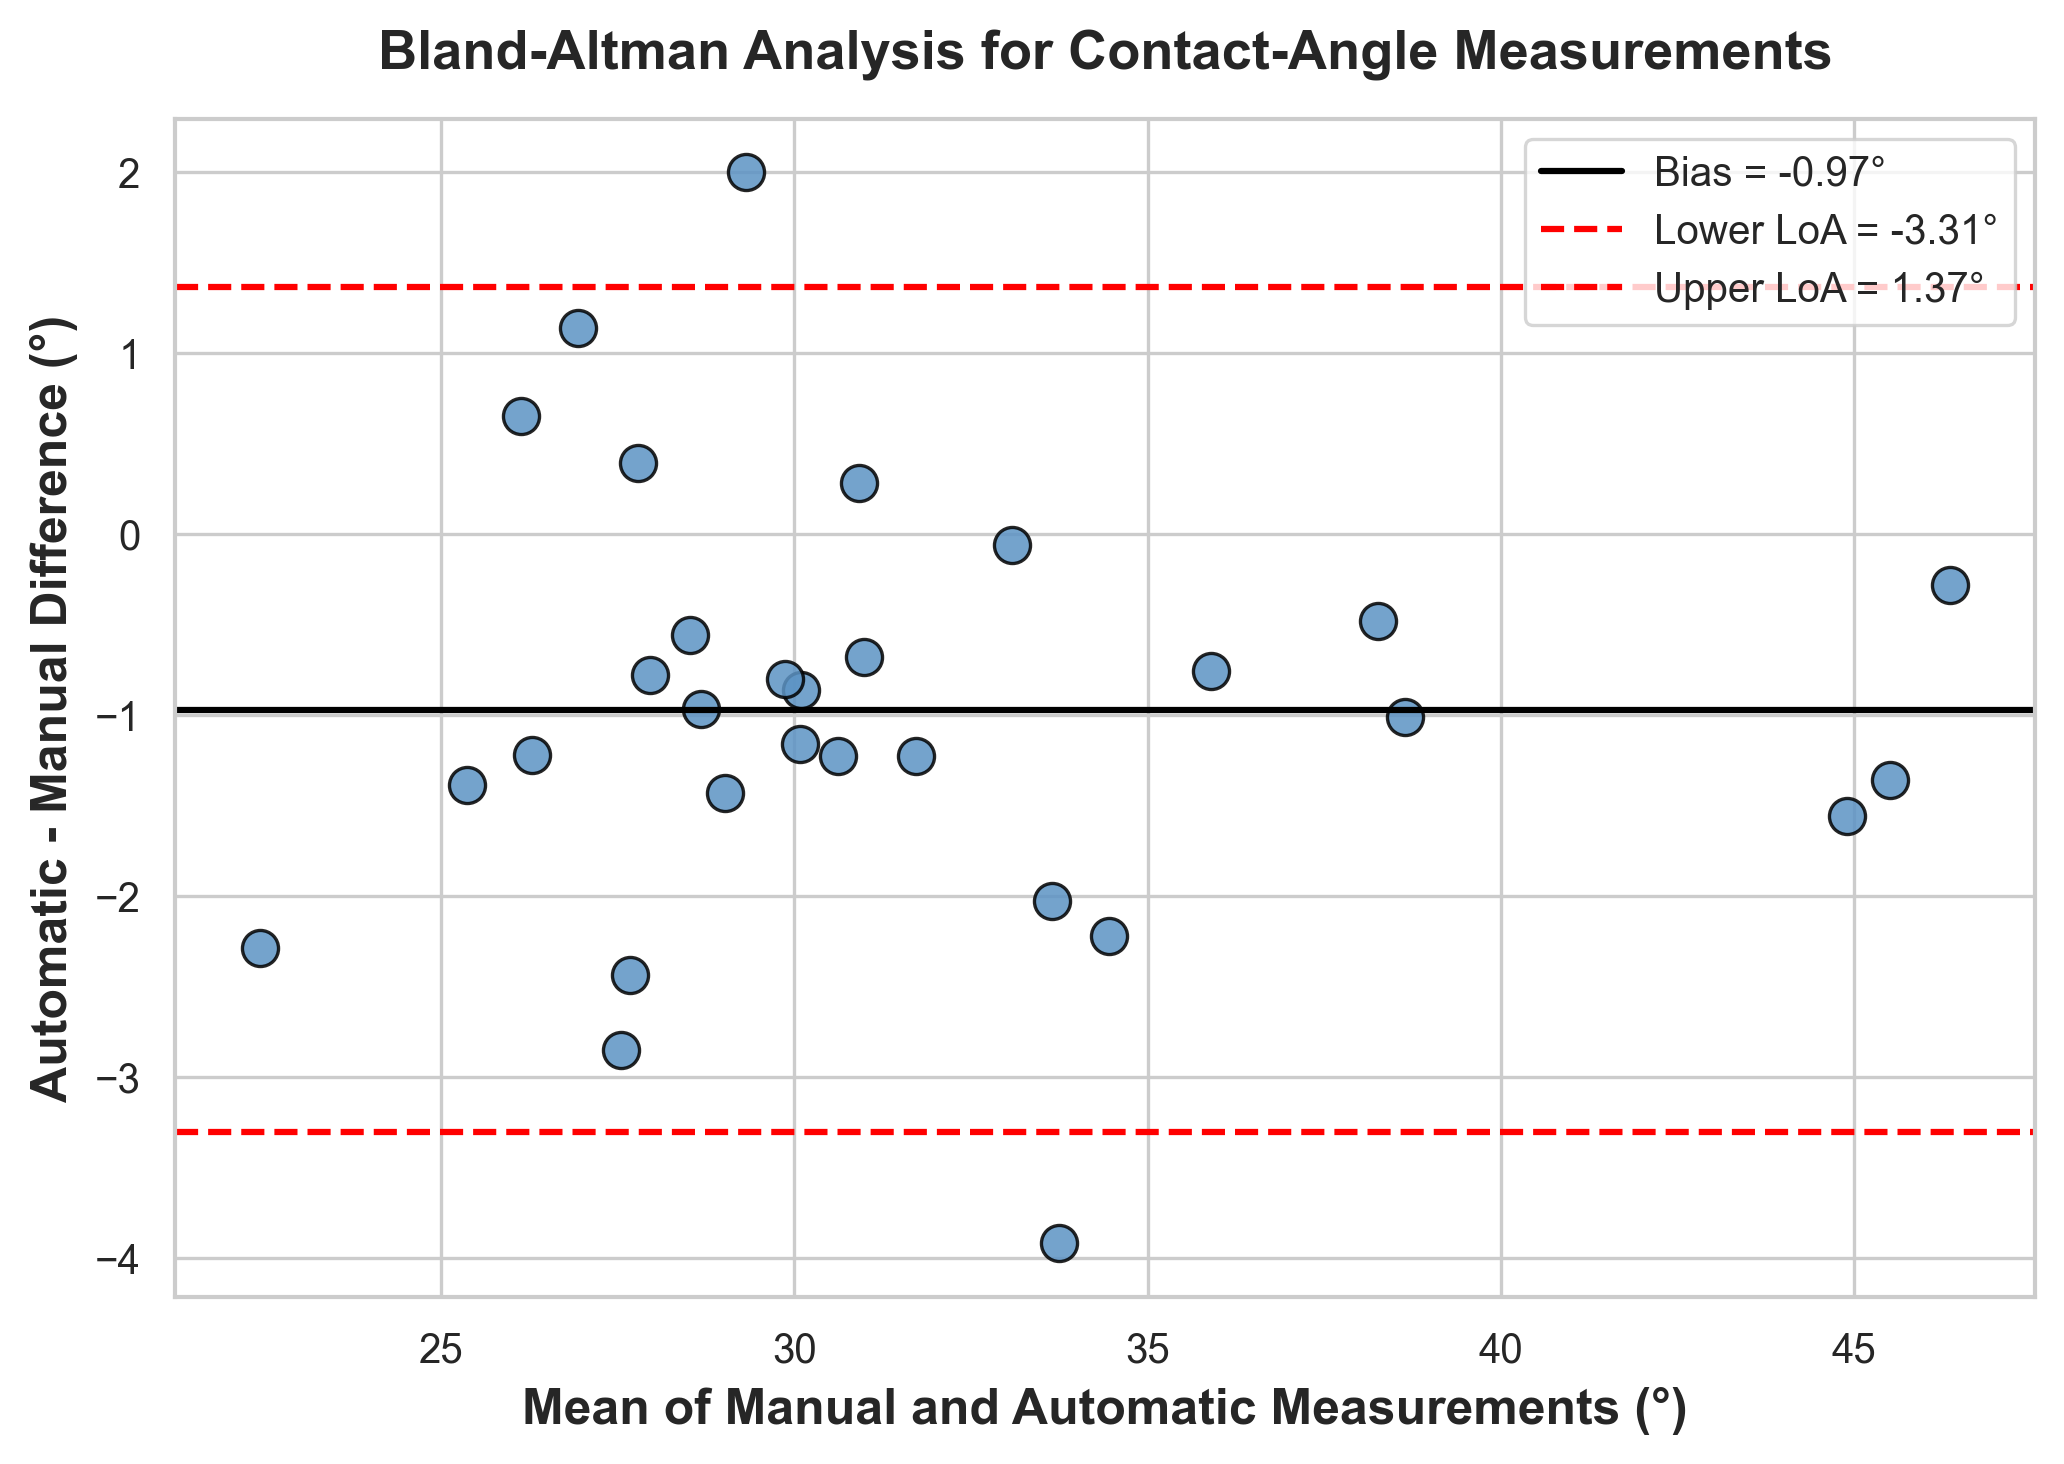

In [5]:
# 1. Load Data & Validation Filter
df_val = df.dropna(subset=['Average Angle Fiji (deg)']).copy()

x_manual = df_val['Average Angle Fiji (deg)'].astype(float)
y_auto = df_val['Contact_Angle'].astype(float)

print(f"Number of validation images: {len(df_val)}")

# 2. Agreement metrics calculation
r2 = r2_score(x_manual, y_auto)
mae = mean_absolute_error(x_manual, y_auto)
rmse = np.sqrt(mean_squared_error(x_manual, y_auto))

reg = linregress(x_manual, y_auto)
slope = reg.slope
intercept = reg.intercept

diff = y_auto - x_manual
bias = np.mean(diff)
sd_diff = np.std(diff, ddof=1)

loa_lower = bias - 1.96 * sd_diff
loa_upper = bias + 1.96 * sd_diff

print("\n=== Manual Fiji vs Automatic Python Agreement Metrics ===")
print(f"R²: {r2:.4f} | MAE: {mae:.2f}° | RMSE: {rmse:.2f}°")
print(f"Parity slope: {slope:.3f} | Intercept: {intercept:.3f}°")
print(f"Mean bias: {bias:.2f}° | 95% LoA: {loa_lower:.2f}° to {loa_upper:.2f}°")

# Save metrics to CSV
metrics_df = pd.DataFrame({
    "Metric": ["R²", "MAE (deg)", "RMSE (deg)", "Parity slope", "Parity intercept (deg)", 
               "Mean bias automatic - manual (deg)", "Lower 95% limit of agreement (deg)", "Upper 95% limit of agreement (deg)"],
    "Value": [r2, mae, rmse, slope, intercept, bias, loa_lower, loa_upper]
})
metrics_df.to_csv("Contact_Angle_Agreement_Metrics.csv", index=False)

# 3. Plotting Parity Plot
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(x_manual, y_auto, color='#5c93c4', edgecolors='black', linewidth=0.8, s=75, alpha=0.85, label='Measured droplets')

min_val = min(x_manual.min(), y_auto.min()) - 2
max_val = max(x_manual.max(), y_auto.max()) + 2
lims = [min_val, max_val]

plt.plot(lims, lims, color='red', linestyle='--', linewidth=2, label='1:1 parity line')

x_fit = np.linspace(min_val, max_val, 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='black', linestyle='-', linewidth=1.5, label='Linear fit')

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('Manual Measurement - Fiji (°)', fontweight='bold', fontsize=12)
plt.ylabel('Automatic Measurement - Python (°)', fontweight='bold', fontsize=12)
plt.title('Agreement Between Manual Fiji and Automatic Python Measurements', fontweight='bold', fontsize=13, pad=12)

text = f"$R^2$ = {r2:.3f}\nMAE = {mae:.2f}°\nRMSE = {rmse:.2f}°\nSlope = {slope:.3f}\nIntercept = {intercept:.2f}°"
plt.annotate(text, xy=(0.05, 0.95), xycoords='axes fraction', fontsize=11, va='top', ha='left',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1))
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig("Validation_Parity_Plot.png", dpi=300, bbox_inches='tight')
plt.savefig("Validation_Parity_Plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

# 4. Plotting Bland-Altman Plot
mean_angles = (x_manual + y_auto) / 2
plt.figure(figsize=(7, 5), dpi=300)
plt.scatter(mean_angles, diff, color='#5c93c4', edgecolors='black', linewidth=0.8, s=75, alpha=0.85)

plt.axhline(bias, color='black', linestyle='-', linewidth=1.5, label=f'Bias = {bias:.2f}°')
plt.axhline(loa_lower, color='red', linestyle='--', linewidth=1.5, label=f'Lower LoA = {loa_lower:.2f}°')
plt.axhline(loa_upper, color='red', linestyle='--', linewidth=1.5, label=f'Upper LoA = {loa_upper:.2f}°')

plt.xlabel('Mean of Manual and Automatic Measurements (°)', fontweight='bold', fontsize=12)
plt.ylabel('Automatic - Manual Difference (°)', fontweight='bold', fontsize=12)
plt.title('Bland-Altman Analysis for Contact-Angle Measurements', fontweight='bold', fontsize=13, pad=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("Bland_Altman_Contact_Angle.png", dpi=300, bbox_inches='tight')
plt.savefig("Bland_Altman_Contact_Angle.pdf", dpi=300, bbox_inches='tight')
plt.show()

Total replicate-level data points evaluated: 96


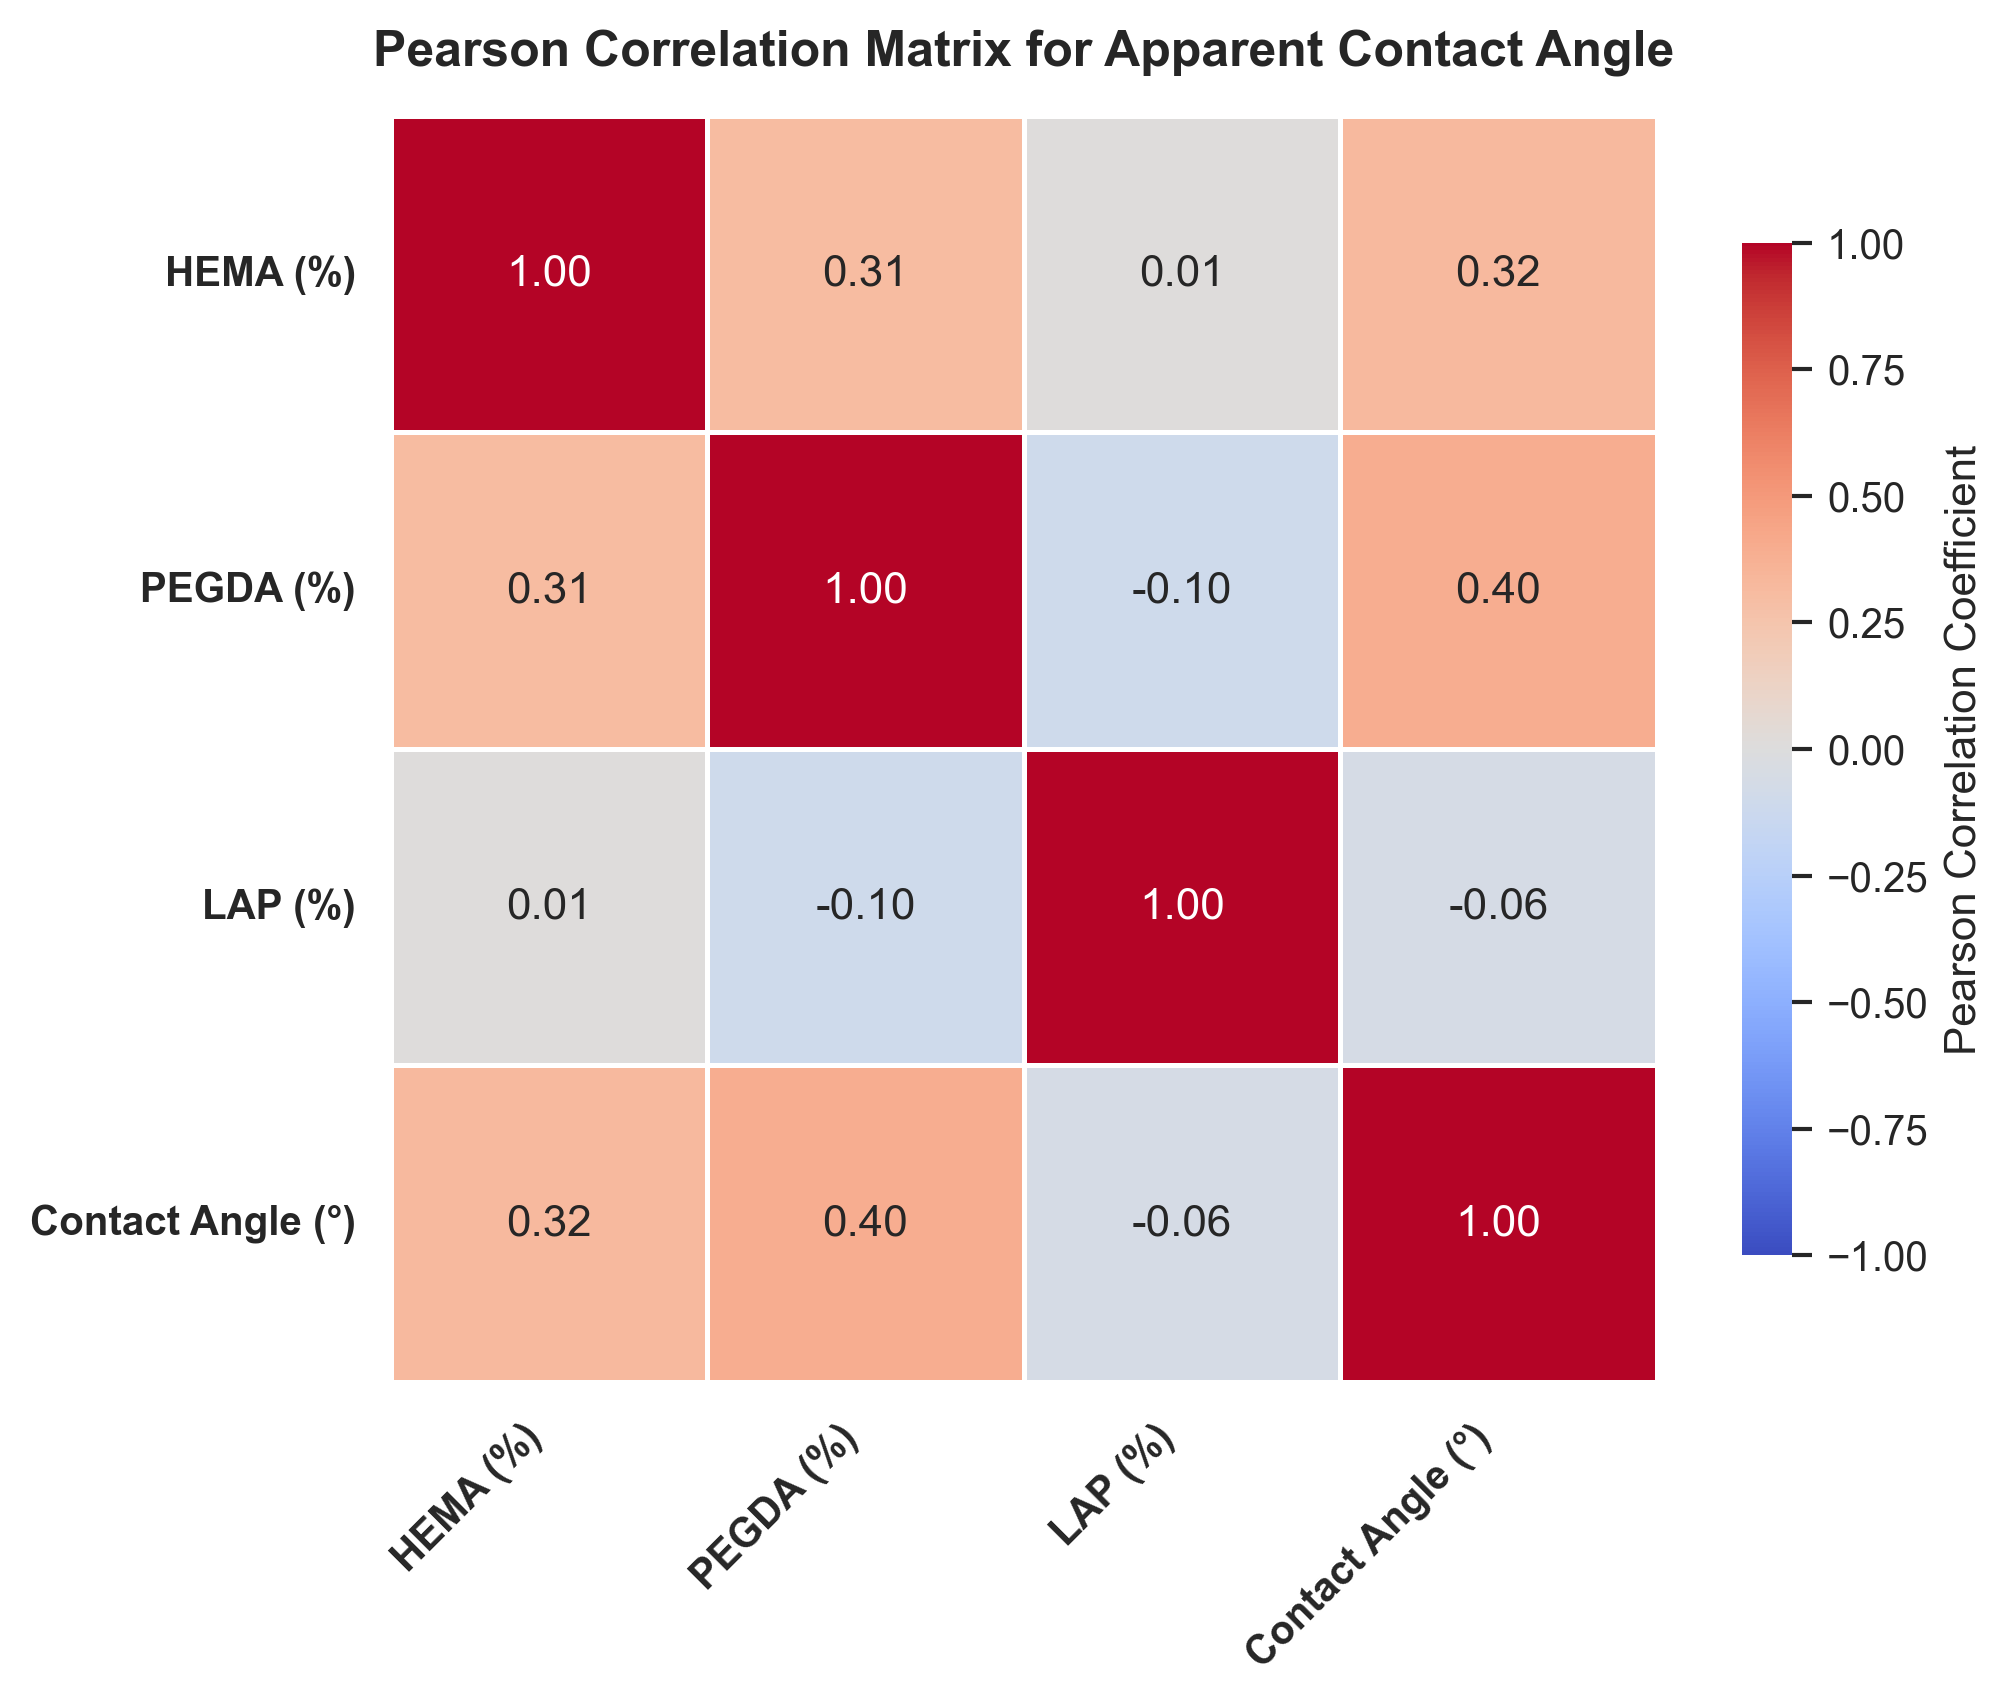

In [6]:
"""
Pearson Correlation Matrix for Apparent Contact Angle using the full replicate dataset.
Water content and formulation-level averaging are removed per reviewer criteria.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =========================================================
# 0. General style & Theme setup
# =========================================================
sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.rcParams["font.family"] = "sans-serif"

# =========================================================
# 1. Target & Independent Variables
# =========================================================
df_corr = df.copy()

# Target column for Contact Angle (Apparent Short-Time Contact Angle)
target_ca = "Contact Angle (°)"

if "Contact Angle (°)" not in df_corr.columns:
    if "Contact_Angle" in df_corr.columns:
        df_corr = df_corr.rename(columns={"Contact_Angle": target_ca})
    elif "Apparent_WCA" in df_corr.columns:
        df_corr = df_corr.rename(columns={"Apparent_WCA": target_ca})

# Independent features ONLY (Water (%) is intentionally excluded)
chem_cols = ["HEMA (%)", "PEGDA (%)", "LAP (%)"]

# Filter complete cases across all replicates
df_corr_clean = df_corr[chem_cols + [target_ca]].dropna()

print(f"Total replicate-level data points evaluated: {len(df_corr_clean)}")

# =========================================================
# 2. Compute Pearson Matrix across ALL REPLICATES
# =========================================================
corr = df_corr_clean.corr(method="pearson")

# =========================================================
# 3. Plot Heatmap
# =========================================================
plt.figure(figsize=(7.2, 5.8), dpi=300)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",      
    vmax=1.0,
    vmin=-1.0,
    square=True,
    linewidths=0.8,
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson Correlation Coefficient"
    },
)

plt.title(
    "Pearson Correlation Matrix for Apparent Contact Angle",
    fontweight="bold",
    fontsize=12,
    pad=12,
)

plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")

plt.tight_layout()

# Save the updated matrix figures
plt.savefig("contact_angle_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("contact_angle_correlation_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()